In [2]:
import pandas
import numpy
import matplotlib
import seaborn
import nltk
import sklearn

print("All required libraries are installed!")

All required libraries are installed!


In [3]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
import sys
print(sys.executable)

c:\Program Files\Python314\python.exe


In [1]:
import pandas

print("Pandas version:", pandas.__version__)
print("Pandas is working! ✅")

Pandas version: 3.0.6
Pandas is working! ✅


In [2]:
import numpy
import matplotlib
import seaborn
import nltk
import sklearn

print("✅ ALL LIBRARIES ARE WORKING!")

✅ ALL LIBRARIES ARE WORKING!


In [2]:
import pandas as pd

file_path = r"C:\Users\HP\Downloads\20 & 21st June Files\Files\spam.csv"

sms = pd.read_csv(file_path, encoding="latin-1")

print("Dataset loaded successfully!")
print("Shape:", sms.shape)

sms.head()

Dataset loaded successfully!
Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Remove unnecessary columns
sms = sms.iloc[:, :2]

# Rename columns
sms.columns = ["label", "message"]

# Check the cleaned dataset
print("Shape after cleaning:", sms.shape)

sms.head()

Shape after cleaning: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(sms["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
sms["label_num"] = sms["label"].map({
    "ham": 0,
    "spam": 1
})

sms.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [6]:
# Now i'm doing the NLP part: removing punctuation and common English stopwords.
import string
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words("english"))

def text_process(text):
    # Remove punctuation
    text = "".join(
        char for char in text
        if char not in string.punctuation
    )

    # Remove stopwords
    words = [
        word for word in text.split()
        if word.lower() not in STOPWORDS
    ]

    return " ".join(words)

sms["clean_msg"] = sms["message"].apply(text_process)

sms[["message", "clean_msg"]].head()

,message,clean_msg
0,"Go until jurong point, crazy.. Available only ...",Go jurong point crazy Available bugis n great ...
1,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry 2 wkly comp win FA Cup final tkts 2...
3,U dun say so early hor... U c already then say...,U dun say early hor U c already say
4,"Nah I don't think he goes to usf, he lives aro...",Nah dont think goes usf lives around though


In [7]:
print("ORIGINAL:")
print(sms["message"].iloc[2])

print("\nCLEANED:")
print(sms["clean_msg"].iloc[2])

ORIGINAL:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

CLEANED:
Free entry 2 wkly comp win FA Cup final tkts 21st May 2005 Text FA 87121 receive entry questionstd txt rateTCs apply 08452810075over18s


In [8]:
from sklearn.model_selection import train_test_split

X = sms["clean_msg"]
y = sms["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=1,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4179
Testing messages: 1393


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4179, 7988)
Testing TF-IDF shape: (1393, 7988)


In [10]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully! ✅")

Naive Bayes model trained successfully! ✅


In [11]:
y_pred = nb_model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9662598707824839
Accuracy percentage: 96.63 %


[[1206    0]
 [  47  140]]


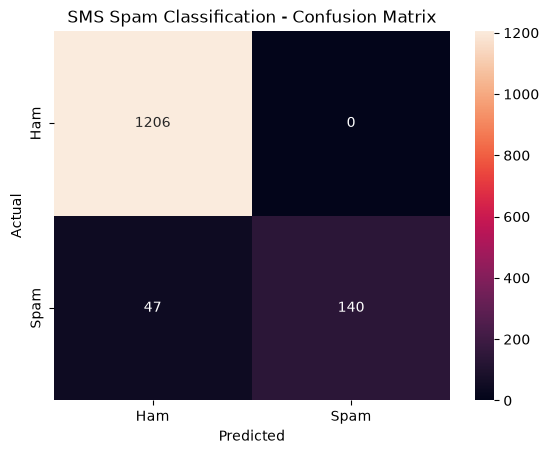

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SMS Spam Classification - Confusion Matrix")
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98      1206
        Spam       1.00      0.75      0.86       187

    accuracy                           0.97      1393
   macro avg       0.98      0.87      0.92      1393
weighted avg       0.97      0.97      0.96      1393



In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=1
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 0.9583632447954056
Logistic Regression Accuracy: 95.84 %


In [16]:
print("========== MODEL COMPARISON ==========")

print(
    "Naive Bayes:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Logistic Regression:",
    round(lr_accuracy * 100, 2),
    "%"
)

========== MODEL COMPARISON ==========
Naive Bayes: 96.63 %
Logistic Regression: 95.84 %


In [18]:
def predict_sms(message):

    # Clean the message
    cleaned_message = text_process(message)

    # Convert to TF-IDF
    message_tfidf = vectorizer.transform([cleaned_message])

    # Predict
    prediction = lr_model.predict(message_tfidf)[0]

    # Probability
    probability = lr_model.predict_proba(message_tfidf)[0][1]

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    print("Message:", message)
    print("Prediction:", result)
    print("Spam Probability:", round(probability * 100, 2), "%")

In [19]:
predict_sms(
    "Congratulations! You have won a free iPhone. Click this link now!"
)

Message: Congratulations! You have won a free iPhone. Click this link now!
Prediction: HAM
Spam Probability: 38.34 %


In [20]:
predict_sms(
    "Hey, are you coming to the gym tomorrow?"
)

Message: Hey, are you coming to the gym tomorrow?
Prediction: HAM
Spam Probability: 3.94 %
